In [1]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import numpy as np
import pandas as pd

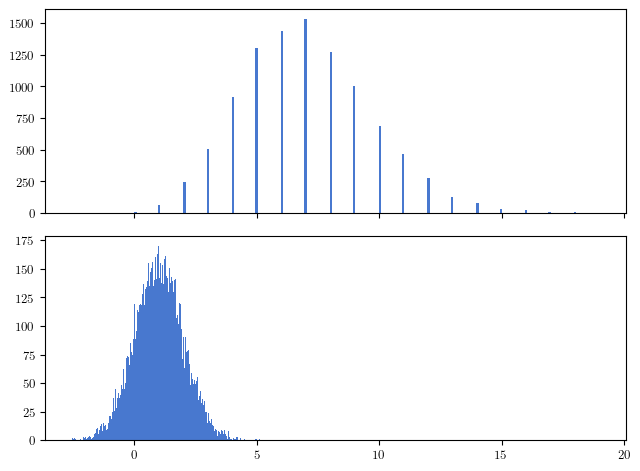

In [2]:
plt.style.use("seaborn-v0_8-muted")
def set_size(width_pt=472.31595, fraction=1, subplots=(1, 1)):
    """Set figure dimensions nicely

    Parameters
    ----------
    width_pt: float
            Document width in points
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    golden_ratio = (5 ** .5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])

    return fig_width_in, fig_height_in

# Colormap with University colors
colors = ["white", "#005f9b", "#153268"]
nodes = [0.0, 0.8, 1.0]
unimap = matplotlib.colors.LinearSegmentedColormap.from_list("unimap", list(zip(nodes, colors)))
unimap_r = unimap.reversed()
try:
    matplotlib.colormaps.register(cmap=unimap)
    matplotlib.colormaps.register(cmap=unimap_r)
except ValueError:
    pass

# LaTeX text renderer
plt.rcParams.update({
    "font.family": "serif",  # use serif/main font for text elements
    "font.serif": "Computer Modern Roman",
    "text.usetex": True,  # use inline math for ticks
    "text.latex.preamble": r"\usepackage{amsmath}",
    "pgf.rcfonts": False,  # don't setup fonts from rc parameters
    # Use 10pt font in plots, to match 10pt font in document
    "axes.labelsize": 10,
    "font.size": 10.95,
    # Make the legend/label fonts a little smaller
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    # Cmap
    "image.cmap": "unimap"
})
 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=set_size(fraction=1, subplots=(1.2, 1)), sharex=True)

ax1.hist(np.random.poisson(7, 10000), bins=200)
ax2.hist(np.random.normal(1, 1, 10000), bins=200)

plt.tight_layout()
plt.show()
fig.savefig('style.pdf', format='pdf', bbox_inches='tight', dpi=300)

In [3]:
import os

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from collections import defaultdict

In [5]:
baseline_meanlists = {}
baseline_compute_max_map = defaultdict(list)

for checkpoint in os.listdir("data/1x/"):
    dlist = []
    
    for csvfile in os.listdir(f"data/1x/{checkpoint}/baseline/"):
        data = pd.read_csv(f"data/1x/{checkpoint}/baseline/{csvfile}")
    
        dlist.append(data["TRA"].to_list())
        baseline_compute_max_map[int(checkpoint)].append(max(data["TRA"].to_list()))

    meanlist = []
    for idx in range(max([len(x) for x in dlist])):
        i = 0
        summe = 0
        for dl in dlist:
            try:
                summe += dl[idx]
                i += 1
            except:
                pass
        meanlist.append(summe / i)
    baseline_meanlists[checkpoint] = meanlist

In [6]:
meanlists = {}
treatment_compute_max_map = defaultdict(list)

for checkpoint in os.listdir("data/1x/"):
    dlist = []

    if checkpoint == '2399':
        continue
        
    for csvfile in os.listdir(f"data/1x/{checkpoint}/witheffects/"):
        data = pd.read_csv(f"data/1x/{checkpoint}/witheffects/{csvfile}")
    
        dlist.append(data["TRA"].to_list())
        treatment_compute_max_map[int(checkpoint)].append(max(data["TRA"].to_list()))

    meanlist = []
    for idx in range(max([len(x) for x in dlist])):
        i = 0
        summe = 0
        for dl in dlist:
            try:
                summe += dl[idx]
                i += 1
            except:
                pass
        meanlist.append(summe / i)
    meanlists[checkpoint] = meanlist

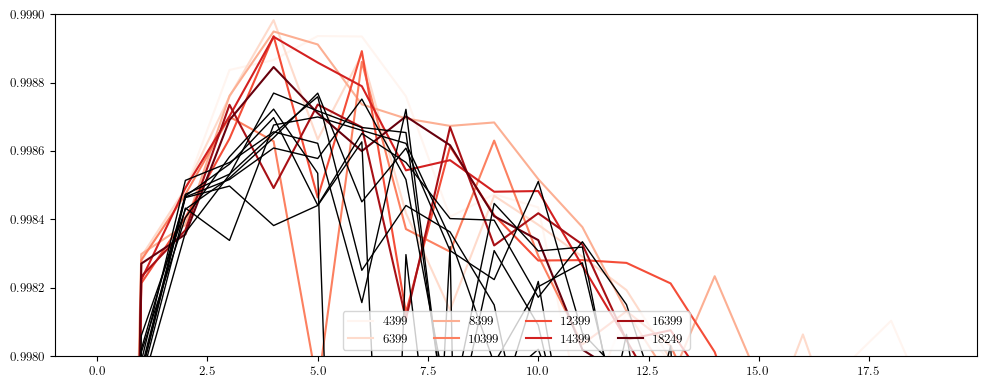

In [7]:
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.figure(figsize=(10, 4))

# Ensure numeric sorting of keys
sorted_keys = sorted(meanlists.keys(), key=int)

# Normalize key values for color mapping
key_values = [int(k) for k in sorted_keys]
norm = mpl.colors.Normalize(vmin=min(key_values), vmax=max(key_values))
cmap = plt.cm.Reds

# Plot main curves with increasing red intensity
for k in sorted_keys:
    color = cmap(norm(int(k)))
    plt.plot(meanlists[k][:20], label=str(k), color=color)

# Plot baselines in black (no legend entries)
for ml in baseline_meanlists.values():
    plt.plot(ml[:20], color='black', linewidth=1)

plt.ylim(0.998, 0.999)
plt.legend(loc="lower center", ncol=4, fontsize=9)
plt.tight_layout()
plt.show()


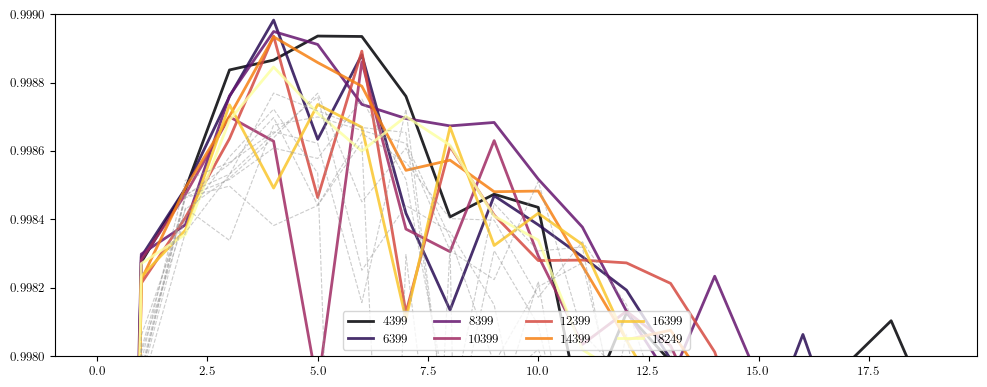

In [8]:
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.figure(figsize=(10, 4))

# Numerically sort keys
sorted_keys = sorted(meanlists.keys(), key=int)

# Normalize key values for colormap scaling
key_values = [int(k) for k in sorted_keys]
norm = mpl.colors.Normalize(vmin=min(key_values), vmax=max(key_values))
cmap = plt.cm.inferno

for k in sorted_keys:
    color = cmap(norm(int(k)))
    plt.plot(
        meanlists[k][:20],
        label=str(k),
        color=color,
        linewidth=2.0,
        alpha=0.85
    )


# Plot baselines as faint reference curves
for ml in baseline_meanlists.values():
    plt.plot(
        ml[:20],
        linestyle="--",
        color="0.6",      # neutral gray
        linewidth=0.8,
        alpha=0.5,
        label="_nolegend_"
    )


plt.ylim(0.998, 0.999)
plt.legend(loc="lower center", ncol=4, fontsize=9)
plt.tight_layout()
plt.show()


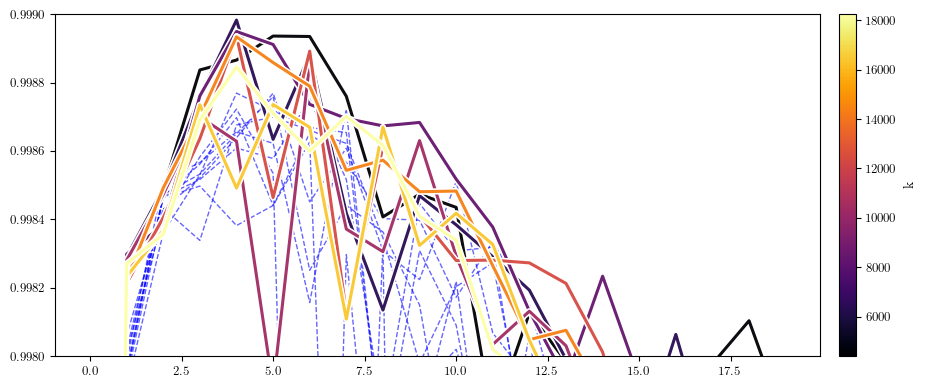

In [9]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(10, 4))

sorted_keys = sorted(meanlists.keys(), key=int)
key_values = [int(k) for k in sorted_keys]

norm = mpl.colors.Normalize(vmin=min(key_values), vmax=max(key_values))
cmap = plt.cm.inferno

# Colored series with white halo
for k in sorted_keys:
    color = cmap(norm(int(k)))
    (line,) = ax.plot(
        meanlists[k][:20],
        color=color,
        linewidth=2.2,
        alpha=0.95,
        zorder=int(k),
    )
    line.set_path_effects([
        pe.Stroke(linewidth=4.5, foreground="white"),
        pe.Normal()
    ])

# Baselines
for ml in baseline_meanlists.values():
    ax.plot(ml[:20], "--", color="blue", linewidth=1, alpha=0.6, zorder=0)

ax.set_ylim(0.998, 0.999)

# Colorbar keyed to k
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("k")

fig.tight_layout()
plt.show

plt.savefig("transfer_learning_compute_scaling_fluo_draft.pdf")

Slope (m):     -6.91254e-09
Intercept (b): 0.999073
R²:            0.156697


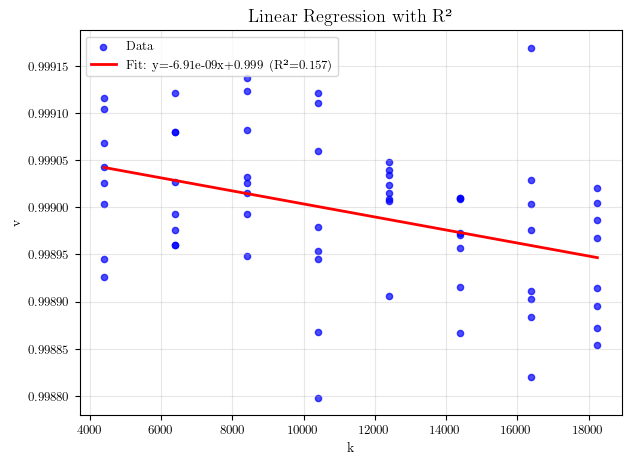

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --- Flatten baseline_compute_max_map into x/y arrays ---
x = []
y = []

for k, l in treatment_compute_max_map.items():
    for v in l:
        x.append(k)
        y.append(v)

x = np.asarray(x, dtype=float)
y = np.asarray(y, dtype=float)

if x.size < 2:
    raise ValueError("Need at least 2 (k, v) points to fit a regression.")

# --- Linear regression: y = m*x + b ---
m, b = np.polyfit(x, y, 1)
y_pred = m * x + b

# --- R^2 ---
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared = 1.0 - (ss_res / ss_tot) if ss_tot != 0 else np.nan

print(f"Slope (m):     {m:.6g}")
print(f"Intercept (b): {b:.6g}")
print(f"R²:            {r_squared:.6g}")

# --- Plot points + regression line ---
plt.figure(figsize=(7, 5))
plt.scatter(x, y, c="blue", s=20, alpha=0.7, label="Data")

# Smooth line across the x-range
x_line = np.linspace(x.min(), x.max(), 200)
y_line = m * x_line + b
plt.plot(x_line, y_line, c="red", linewidth=2, label=f"Fit: y={m:.3g}x+{b:.3g} (R²={r_squared:.3f})")

plt.xlabel("k")
plt.ylabel("v")
plt.title("Linear Regression with R²")
plt.grid(True, alpha=0.3)
plt.legend()


plt.savefig("transfer_learning_regression.pdf")

### Same plot as in embeddingeffects

In [11]:
withs = []

for fname in os.listdir("data/1x/18249/witheffects/"):
    withs.append(list(pd.read_csv("data/1x/18249/witheffects/"+fname)["LNK"])[:27])

withouts = []

for fname in os.listdir("data/1x/18249/baseline/"):
    withouts.append(list(pd.read_csv("data/1x/18249/baseline/"+fname)["LNK"])[:27])

In [12]:
# Load linking performance from baseline experiment
bl_withs = []



for fname in os.listdir("../../results/data/fluo/original_maester_embeddings/"):
    bl_withs.append(list(pd.read_csv("../../results/data/fluo/original_maester_embeddings/"+fname)["LNK"])[:27])

bl_withouts = []

for fname in os.listdir("../../results/data/fluo/without/"):
    bl_withouts.append(list(pd.read_csv("../../results/data/fluo/without/"+fname)["LNK"])[:27])

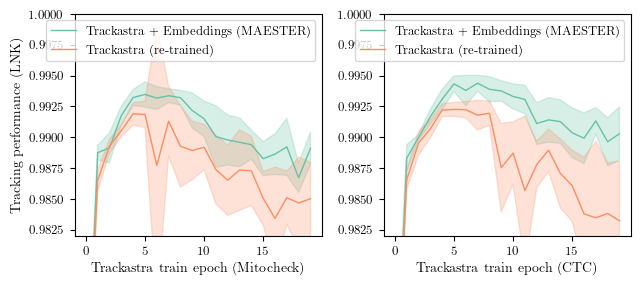

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

#fig, ax = plt.subplots(1, 2, figsize=(14,5))
#fig, ax = plt.subplots(1, 2, figsize=set_size(fraction=1, subplots=(1.2, 2)))
fig, ax = plt.subplots(1, 2, figsize=set_size(fraction=1, subplots=(1, 1.35)))

cmap = mpl.colormaps['Set2']
ca, cb = cmap(0), cmap(1)

def plot_mean_shaded(ax, data, color, label, maxlen=None):
    arr = np.array([d[:maxlen] for d in data])
    mean = arr.mean(axis=0)
    std  = arr.std(axis=0)

    x = np.arange(len(mean))
    ax.plot(x, mean, color=color, label=label, linewidth=1)
    ax.fill_between(x, mean-std, mean+std, color=color, alpha=0.25)

# left: zoomed (first 20)
plot_mean_shaded(ax[0], withs, ca, "Trackastra + Embeddings (MAESTER)", maxlen=20)
plot_mean_shaded(ax[0], withouts, cb, "Trackastra (re-trained)", maxlen=20)
ax[0].set_ylim(0.982, 1.0)
ax[0].legend()

# right: entire sequence
#plot_mean_shaded(ax[1], withs, ca, "With")
#plot_mean_shaded(ax[1], withouts, cb, "Without")
#ax[1].set_ylim(0.90, 1.0)
#ax[1].legend()

plot_mean_shaded(ax[1], bl_withs, ca, "Trackastra + Embeddings (MAESTER)", maxlen=20)
plot_mean_shaded(ax[1], bl_withouts, cb, "Trackastra (re-trained)", maxlen=20)
ax[1].set_ylim(0.982, 1.0)
ax[1].legend(loc='upper right')

ax[0].set_xlabel("Trackastra train epoch (Mitocheck)")
ax[1].set_xlabel("Trackastra train epoch (CTC)")

ax[0].set_ylabel("Tracking performance (LNK)")

# Leave room at the bottom for the legend
fig.tight_layout()

plt.savefig("FINAL_b_pretraining_transfer.pdf")

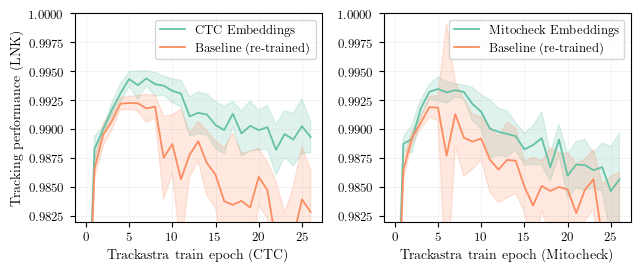

In [68]:
fig, ax = plt.subplots(1, 2, figsize=set_size(fraction=1, subplots=(1, 1.3)))

def plot_mean_shaded(ax, data, color, label, maxlen=None):
    arr = np.array([d[:maxlen] for d in data])
    mean = arr.mean(axis=0)
    std  = arr.std(axis=0)
    x = np.arange(len(mean))

    ax.plot(x, mean, color=color, label=label, linewidth=1.3)
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.20)

plot_mean_shaded(ax[1], withs, ca, "Mitocheck Embeddings", maxlen=30)
plot_mean_shaded(ax[1], withouts, cb, "Baseline (re-trained)", maxlen=30)
ax[1].set_ylim(0.982, 1.0)
ax[1].set_xlabel("Trackastra train epoch (Mitocheck)")
ax[0].set_ylabel("Tracking performance (LNK)")

plot_mean_shaded(ax[0], bl_withs, ca, "CTC Embeddings", maxlen=30)
plot_mean_shaded(ax[0], bl_withouts, cb, "Baseline (re-trained)", maxlen=30)
ax[0].set_ylim(0.982, 1.0)
ax[0].set_xlabel("Trackastra train epoch (CTC)")

for a in ax:
    a.grid(True, linewidth=0.4, alpha=0.25)


ax[1].legend(
    loc="upper right",
    frameon=True
)

ax[0].legend(
    loc="upper right",
    frameon=True
)

fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig("FINAL_b_pretraining_transfer.pdf", bbox_inches="tight")